## Common pitfalls and best practices

Notebook 9 ended by making the leakage rule structural. Imputers, scalers, encoders, vectorisers, group aggregates and selectors all live inside a `Pipeline` now, every one of them refits on the training fold, and there is no code path where `predict` refits anything. That closes off the entire family of mistakes the series spent eight notebooks warning about.

It also closes off exactly none of the mistakes in this notebook.

A pipeline is a statement about **when** a transformer is allowed to learn. It has nothing to say about whether a column should have been collected in the first place, whether that column will exist when you need to predict, or whether the score you are reading has been quietly spent. Those three failures pass through a correct pipeline without touching the sides, and all three of them are invisible to cross-validation.

**What this notebook covers:**

1. A column that exists because of the answer
2. A feature that will not be there when you need it
3. The validation set you used up
4. Over-engineering, measured on real data
5. The model was fine, the world moved
6. The metric is a business decision, not a modelling one
7. Working by hypothesis, and writing down why each feature is there
8. What the series covered

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (StandardScaler, OneHotEncoder, OrdinalEncoder,
                                   TargetEncoder, FunctionTransformer)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split, KFold
from sklearn.metrics import roc_auc_score, r2_score, recall_score, f1_score, precision_score

SEED = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def new_lr():
    return LogisticRegression(max_iter=2000, random_state=SEED)

In [2]:
telco = pd.read_csv('datasets/telco_churn.csv')
telco['TotalCharges'] = pd.to_numeric(telco['TotalCharges'], errors='coerce')
telco = telco[telco['tenure'] > 0].reset_index(drop=True)

SERVICES = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
            'StreamingMovies']
telco['bundle'] = telco[SERVICES].apply(lambda row: '|'.join(row.astype(str)), axis=1)

y = (telco['Churn'] == 'Yes').astype(int)
X = telco.drop(columns=['Churn'])

NUMERIC = ['tenure', 'MonthlyCharges', 'TotalCharges']
NOMINAL = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
           'PaperlessBilling', 'PaymentMethod', 'InternetService']
CONTRACT_ORDER = [['Month-to-month', 'One year', 'Two year']]

def count_services(frame):
    return frame.isin(['Yes', 'DSL', 'Fiber optic']).sum(axis=1).to_frame('num_services')

def service_feature_names(transformer, input_features):
    return ['num_services']

service_counter = FunctionTransformer(count_services, feature_names_out=service_feature_names)

def make_preprocessor(extra_numeric=()):
    """Notebook 9's preprocessor, with a hook for adding a column to the numeric group."""
    return ColumnTransformer([
        ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                          ('scale', StandardScaler())]), NUMERIC + list(extra_numeric)),
        ('svc', Pipeline([('count', service_counter), ('scale', StandardScaler())]), SERVICES),
        ('ord', OrdinalEncoder(categories=CONTRACT_ORDER), ['Contract']),
        ('nom', OneHotEncoder(handle_unknown='ignore', drop='if_binary',
                              sparse_output=False), NOMINAL),
        ('hi',  TargetEncoder(random_state=SEED), ['bundle']),
    ], remainder='drop', verbose_feature_names_out=False)

def make_pipe(extra_numeric=()):
    return Pipeline([('prep', make_preprocessor(extra_numeric)), ('model', new_lr())])

honest = cross_val_score(make_pipe(), X, y, cv=CV, scoring='roc_auc', n_jobs=1)
print('the honest pipeline from notebook 9: %.4f' % honest.mean())

the honest pipeline from notebook 9: 0.8416


Everything in this notebook is measured against that 0.8416. Having a number we trust is what makes the failures below legible: when something reports 0.98, we know precisely how much of it is a lie.

### 1. A column that exists because of the answer

Target leakage is a column that was written down **after** the thing you are predicting happened, or because it happened. The model is not learning to predict the outcome, it is learning to read a record of the outcome.

Telco has no such column, so we are going to add one, and it is worth saying plainly that this part is constructed. Suppose the support system logs a `cancellation_ticket` when a customer phones in to cancel. It is a real field, it is populated for real reasons, and 90% of the people who eventually churn have one. It also cannot possibly help you, because by the time it exists the customer has already decided to leave.

In [3]:
rng = np.random.default_rng(SEED)
X_leaky = X.copy()
X_leaky['cancellation_ticket'] = np.where(y == 1,
                                          rng.binomial(1, 0.90, len(y)),   # 90% of churners phone in
                                          rng.binomial(1, 0.02, len(y)))   # 2% of stayers phone in and stay

print('ticket rate among churners %.3f, among stayers %.3f'
      % (X_leaky.loc[y == 1, 'cancellation_ticket'].mean(),
         X_leaky.loc[y == 0, 'cancellation_ticket'].mean()))

leaky = cross_val_score(make_pipe(['cancellation_ticket']), X_leaky, y,
                        cv=CV, scoring='roc_auc', n_jobs=1)
print()
print('honest pipeline  %.4f   folds %s' % (honest.mean(), honest.round(4)))
print('one column added %.4f   folds %s' % (leaky.mean(), leaky.round(4)))
series_gain = 0.8416 - 0.8087      # what all the real feature work in notebooks 1 to 9 was worth
print('the column is worth %+.4f, which is %.1f times everything notebooks 1 to 9 found put together'
      % (leaky.mean() - honest.mean(), (leaky.mean() - honest.mean()) / series_gain))

ticket rate among churners 0.900, among stayers 0.019

honest pipeline  0.8416   folds [0.8517 0.8438 0.8405 0.8372 0.8349]
one column added 0.9809   folds [0.9821 0.9771 0.9792 0.9807 0.9853]
the column is worth +0.1393, which is 4.2 times everything notebooks 1 to 9 found put together


0.9809. In a real project this is the moment to be suspicious rather than pleased, and the useful question is which of your normal checks would have made you suspicious.

In [4]:
print('check 1: is the cross-validation unstable?')
print('  honest pipeline fold spread  %.4f' % honest.std())
print('  leaky pipeline fold spread   %.4f' % leaky.std())
print()
print('check 2: does any single column predict the target implausibly well?')
num_services = X[SERVICES].isin(['Yes', 'DSL', 'Fiber optic']).sum(axis=1)
singles = {
    'cancellation_ticket': X_leaky['cancellation_ticket'],
    'tenure (negated)': -X['tenure'],
    'MonthlyCharges': X['MonthlyCharges'],
    'num_services': num_services,
}
for name, column in singles.items():
    print('  univariate AUC, %-22s %.4f' % (name, roc_auc_score(y, column)))

check 1: is the cross-validation unstable?
  honest pipeline fold spread  0.0059
  leaky pipeline fold spread   0.0028

check 2: does any single column predict the target implausibly well?
  univariate AUC, cancellation_ticket    0.9406
  univariate AUC, tenure (negated)       0.7414
  univariate AUC, MonthlyCharges         0.6203
  univariate AUC, num_services           0.4967


The first check does not merely fail, it points the wrong way. The leaky model's folds agree with each other **more** tightly than the honest model's, 0.0028 against 0.0059. Every stability diagnostic you own will report that the leaky model is the more trustworthy of the two, because a column that encodes the answer encodes it just as reliably in every fold.

The second check works. A single binary column scoring 0.9406 on its own, when the best real column in the file manages 0.7414, is the kind of thing worth an afternoon.

But look at the last row before trusting that rule. `num_services` scores **0.4967**, which is a coin flip, and notebook 7 measured it as worth +0.0109 on the raw numeric baseline (+0.0082 in the chain we rebuild in section 4). Its relationship with churn is an inverted U, and univariate AUC cannot see a non-monotone relationship at all. So the screen that catches the leak also throws away one of the best real features in the series.

The honest summary is uncomfortable:

- a high univariate score is a **prompt to investigate**, not a verdict, and a low one is not a reason to drop anything
- no statistic in this section distinguishes a leaked column from a genuinely excellent one, because the difference between them is not in the numbers
- the difference is **when the value gets written**, which is a question about your data pipeline, not your dataframe

The test that actually works has no code: for every column, ask whether you would know its value at the moment you need the prediction. If the answer needs a conversation with whoever owns the source system, have that conversation.

### 2. A feature that will not be there when you need it

The previous section's column was disqualified by causality. This one is subtler: a feature can be perfectly legitimate, correlate with the target for honest reasons, and still be impossible to compute at prediction time.

Rolling windows are where this happens most often. We are on hourly bike rentals now, where notebook 5 established that ridership has strong daily structure. A 3-hour average of recent demand is an obviously sensible feature. The question is which three hours.

In [5]:
bike = pd.read_csv('datasets/bike_sharing.csv')
bike['dteday'] = pd.to_datetime(bike['dteday'])
bike = bike.sort_values(['dteday', 'hr']).reset_index(drop=True)   # nb5: sort by both, the default sort is unstable
bike['year'] = bike['dteday'].dt.year

counts = bike['cnt']
for window in (3, 24):
    bike['trailing_%d' % window] = counts.shift(1).rolling(window, min_periods=1).mean()
    bike['centred_%d' % window] = counts.rolling(window, center=True, min_periods=1).mean()

print('correlation with the value we are trying to predict:')
for window in (3, 24):
    print('  %2dh trailing (shifted first) %.3f      %2dh centred %.3f'
          % (window, bike['trailing_%d' % window].corr(counts),
             window, bike['centred_%d' % window].corr(counts)))

correlation with the value we are trying to predict:
   3h trailing (shifted first) 0.670       3h centred 0.977
  24h trailing (shifted first) 0.401      24h centred 0.436


In [6]:
BIKE_BASE = ['hr', 'workingday', 'temp', 'hum', 'windspeed', 'weathersit', 'season', 'holiday', 'weekday']

def bike_model(extra):
    return Pipeline([
        ('prep', ColumnTransformer([
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
             ['hr', 'weekday', 'season', 'weathersit']),
            ('scale', StandardScaler(), ['temp', 'hum', 'windspeed'] + extra),
            ('raw', 'passthrough', ['workingday', 'holiday'])])),
        ('model', Ridge(alpha=1.0))])

usable = bike.dropna(subset=['trailing_3']).reset_index(drop=True)
train_2011 = usable[usable['year'] == 2011]
test_2012 = usable[usable['year'] == 2012]

def bike_r2(extra):
    fitted = bike_model(extra).fit(train_2011[BIKE_BASE + extra], train_2011['cnt'])
    return r2_score(test_2012['cnt'], fitted.predict(test_2012[BIKE_BASE + extra]))

print('train on 2011, predict 2012:')
print('  no window feature at all            R2 %.4f' % bike_r2([]))
for window in (3, 24):
    print('  %2dh trailing, shifted (legitimate)  R2 %.4f' % (window, bike_r2(['trailing_%d' % window])))
    print('  %2dh centred (uses future hours)     R2 %.4f' % (window, bike_r2(['centred_%d' % window])))

train on 2011, predict 2012:
  no window feature at all            R2 0.4294
   3h trailing, shifted (legitimate)  R2 0.6774
   3h centred (uses future hours)     R2 0.9716
  24h trailing, shifted (legitimate)  R2 0.5636
  24h centred (uses future hours)     R2 0.6230


Two windows, two different lessons.

At three hours the cheat is enormous and obvious. The centred window contains the hour we are predicting plus the one after it, so the feature is very nearly the answer: it correlates **0.977** with the target and takes R2 from 0.6774 to 0.9716. Nobody deploys that model, because a correlation of 0.977 with the target makes anyone look twice.

At twenty-four hours the cheat is nearly invisible and still real. Correlation goes 0.401 to 0.436, a difference you would never notice in a correlation table, and R2 goes 0.5636 to 0.6230. That is a gain of **0.0594** that will evaporate on the first day in production, and there is no diagnostic in the notebook that flags it.

Note what these two cases do and do not show. They do not show that subtle leaks are worse; the 3-hour cheat is both louder and larger. What they show is that **the dangerous leak is the one that survives review**, and only one of these two would. A correlation of 0.977 with the target gets caught in the first code review. A move from 0.401 to 0.436 gets caught by nobody, and it is still 0.0594 of R2 that will not exist on the first day in production.

The mechanical rule worth memorising, since the series has now hit it three times: **shift before you roll.** `series.shift(1).rolling(w)` only ever sees the past. `series.rolling(w)` includes the current row and `center=True` includes the future. All three are one keystroke apart.

### 3. The validation set you used up

This one is different from the first two. There is no bad column anywhere, no future information, no fitting on the wrong rows. Every individual step is correct, and the failure comes from repeating a correct step.

Notebook 9 measured the beginnings of it: quoting the best of 81 grid-search combinations inflated the score by 0.0001, which was tiny because all 81 candidates agreed with each other. Now we look at the regime where they do not agree, which is what happens whenever a person, rather than a grid, is doing the choosing.

Here is the loop nearly everyone runs. Hold out a validation set. Think of a feature. Add it. Did validation go up? Keep it. Think of another.

To measure what that loop does on its own, we take the human out and feed it features we know are worthless: pure random noise, 200 of them. Any improvement it reports is by definition an illusion. And because a validation set that has been used for decisions is no longer a fair test, we hold back a third split that nothing is allowed to touch.

In [7]:
X_fit, X_rest, y_fit, y_rest = train_test_split(X, y, test_size=0.4, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, test_size=0.5,
                                                random_state=SEED, stratify=y_rest)
print('fit %d rows   validation %d rows   untouched test %d rows' % (len(X_fit), len(X_val), len(X_test)))

prep = make_preprocessor().fit(X_fit, y_fit)
A_fit, A_val, A_test = prep.transform(X_fit), prep.transform(X_val), prep.transform(X_test)

def fit_and_score(fit_cols, val_cols, test_cols):
    model = new_lr().fit(fit_cols, y_fit)
    return (roc_auc_score(y_val, model.predict_proba(val_cols)[:, 1]),
            roc_auc_score(y_test, model.predict_proba(test_cols)[:, 1]))

start_val, start_test = fit_and_score(A_fit, A_val, A_test)
print('before we start:  validation %.4f   untouched test %.4f' % (start_val, start_test))

fit 4219 rows   validation 1406 rows   untouched test 1407 rows
before we start:  validation 0.8126   untouched test 0.8316


In [8]:
noise_rng = np.random.default_rng(0)
cur_fit, cur_val, cur_test = A_fit.copy(), A_val.copy(), A_test.copy()
best_val = start_val
history = [(0, 0, start_val, start_test)]
kept = 0
CANDIDATES = 200

for trial in range(1, CANDIDATES + 1):
    col_fit = noise_rng.normal(size=(len(A_fit), 1))
    col_val = noise_rng.normal(size=(len(A_val), 1))
    col_test = noise_rng.normal(size=(len(A_test), 1))
    val_score, test_score = fit_and_score(np.hstack([cur_fit, col_fit]),
                                          np.hstack([cur_val, col_val]),
                                          np.hstack([cur_test, col_test]))
    if val_score > best_val:                      # the only rule: keep it if validation improves
        best_val = val_score
        kept += 1
        cur_fit = np.hstack([cur_fit, col_fit])
        cur_val = np.hstack([cur_val, col_val])
        cur_test = np.hstack([cur_test, col_test])
        history.append((trial, kept, val_score, test_score))

print('tried %d pure-noise features, kept %d of them' % (CANDIDATES, kept))
print()
print(' after keeping   validation   untouched test')
for trial, k, v, t in history[::6] + [history[-1]]:
    print('   %2d features     %.4f       %.4f' % (k, v, t))
print()
print('validation improved   %+.4f   (%.4f -> %.4f)'
      % (history[-1][2] - start_val, start_val, history[-1][2]))
print('the untouched test    %+.4f   (%.4f -> %.4f)'
      % (history[-1][3] - start_test, start_test, history[-1][3]))

tried 200 pure-noise features, kept 43 of them

 after keeping   validation   untouched test
    0 features     0.8126       0.8316
    6 features     0.8153       0.8310
   12 features     0.8164       0.8304
   18 features     0.8174       0.8301
   24 features     0.8192       0.8295
   30 features     0.8209       0.8305
   36 features     0.8219       0.8301
   42 features     0.8230       0.8296
   43 features     0.8230       0.8298

validation improved   +0.0104   (0.8126 -> 0.8230)
the untouched test    -0.0019   (0.8316 -> 0.8298)


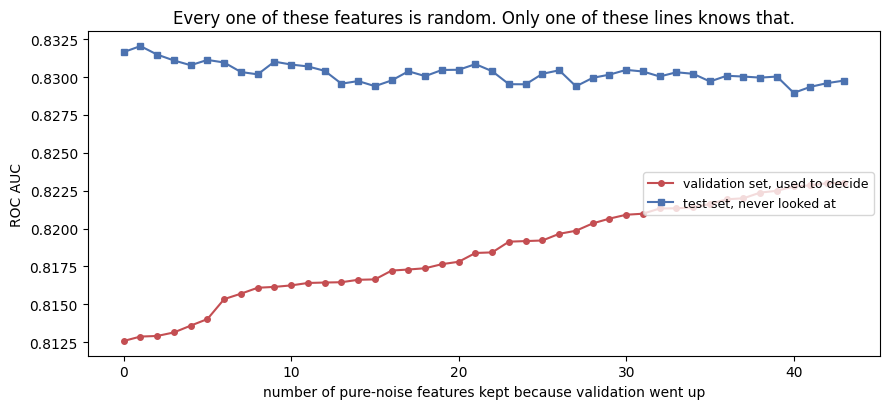

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.2))
kept_axis = [h[1] for h in history]
ax.plot(kept_axis, [h[2] for h in history], 'o-', ms=4, color='#c44e52',
        label='validation set, used to decide')
ax.plot(kept_axis, [h[3] for h in history], 's-', ms=4, color='#4c72b0',
        label='test set, never looked at')
ax.set_xlabel('number of pure-noise features kept because validation went up')
ax.set_ylabel('ROC AUC')
ax.set_title('Every one of these features is random. Only one of these lines knows that.')
ax.legend(loc='center right', fontsize=9)
plt.tight_layout()
plt.show()

The red line climbs by **0.0104** and every point on it is a lie. The blue line, measured on rows that took no part in any decision, moves by -0.0019, which is the correct answer for adding 43 columns of noise.

The number worth sitting with is that 0.0104. Section 5 lists what the real features in this series were worth, and 0.0104 is larger than four of the five. Someone running this loop by hand would have concluded they had found a feature about as valuable as anything notebooks 1 through 8 produced, and they would have been holding nothing at all.

Notice also what did **not** happen. There was no leak. The preprocessor was fitted on the fit rows only, and the validation rows never entered a `fit` call. Notebook 9's pipeline would have been perfectly happy with every step of this, because the mistake is not in any single step. It is in the fact that a held-out set stops being held out the moment you use it to choose, and it degrades a little more with each choice.

Which gives the practical rules:

- keep a final test set that you look at **once**, at the end, when nothing further will be decided
- prefer cross-validated comparisons on the development data, and treat the winner's score as optimistic by construction
- count your decisions. Fifty comparisons against one validation set is fifty chances for it to flatter noise
- **when the validation number is all you have, prefer the feature you can explain.** Notebook 8 said agreement between methods is confirmation and disagreement is a question. This is the same idea applied to yourself: a gain you can tell a causal story about survives replication more often than a gain you cannot

### 4. Over-engineering, measured on real data

The previous section added noise and kept the columns that helped a validation score. This section adds noise and keeps everything, which is the more common shape of the problem: someone generates every ratio, every product and every polynomial term, and hands the pile to the model.

The intuition being violated is that more information cannot hurt. It cannot hurt in principle. It does hurt in practice, because a model with more columns than it needs has more ways to fit the training rows exactly.

In [10]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
prep_oe = make_preprocessor().fit(X_tr, y_tr)
base_tr, base_te = prep_oe.transform(X_tr), prep_oe.transform(X_te)
noise = np.random.default_rng(0)

print('  noise cols   total   train AUC   test AUC       gap')
curve = []
for n_noise in [0, 5, 20, 50, 100, 300, 1000, 3000]:
    extra_tr = noise.normal(size=(len(base_tr), n_noise))
    extra_te = noise.normal(size=(len(base_te), n_noise))
    wide_tr = np.hstack([base_tr, extra_tr])
    wide_te = np.hstack([base_te, extra_te])
    model = LogisticRegression(max_iter=3000, random_state=SEED).fit(wide_tr, y_tr)
    tr_auc = roc_auc_score(y_tr, model.predict_proba(wide_tr)[:, 1])
    te_auc = roc_auc_score(y_te, model.predict_proba(wide_te)[:, 1])
    curve.append((wide_tr.shape[1], tr_auc, te_auc))
    print('  %10d %7d      %.4f     %.4f   %+.4f' % (n_noise, wide_tr.shape[1], tr_auc, te_auc, tr_auc - te_auc))

  noise cols   total   train AUC   test AUC       gap
           0      18      0.8689     0.8220   +0.0469
           5      23      0.8690     0.8218   +0.0472
          20      38      0.8705     0.8204   +0.0501
          50      68      0.8730     0.8149   +0.0581
         100     118      0.8779     0.8124   +0.0655
         300     318      0.8928     0.8026   +0.0902


        1000    1018      0.9471     0.7388   +0.2083


        3000    3018      1.0000     0.6537   +0.3463


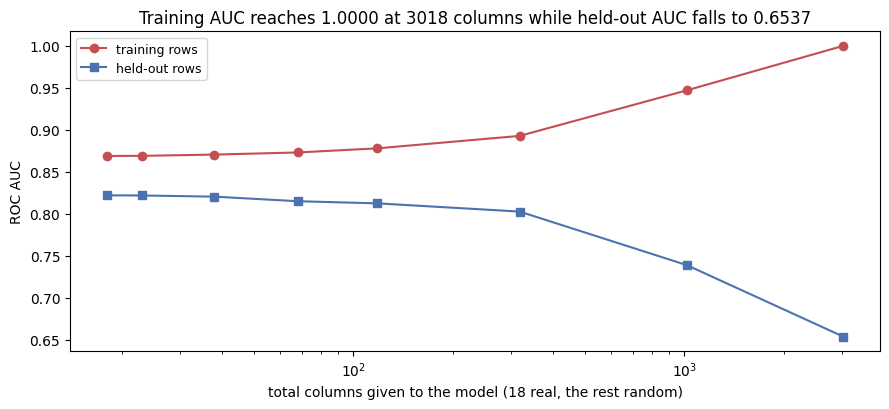

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.2))
widths = [c[0] for c in curve]
ax.plot(widths, [c[1] for c in curve], 'o-', color='#c44e52', label='training rows')
ax.plot(widths, [c[2] for c in curve], 's-', color='#4c72b0', label='held-out rows')
ax.set_xscale('log')
ax.set_xlabel('total columns given to the model (18 real, the rest random)')
ax.set_ylabel('ROC AUC')
ax.set_title('Training AUC reaches %.4f at %d columns while held-out AUC falls to %.4f'
             % (curve[-1][1], curve[-1][0], curve[-1][2]))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

At 3,018 columns and 4,922 training rows the model separates the training data **perfectly**, AUC 1.0000, and scores 0.6537 on held-out rows against the 0.8220 it managed with the 18 real columns alone. It has memorised its way to a worse model.

The detail worth noticing is the first row of that table, where the gap is already **+0.0469** with no noise at all. A train-test gap is not by itself evidence of anything wrong; models fit their training data better than anything else, always. What tells you something is the gap **growing** while the held-out number falls.

The other half of over-engineering is quieter, and there is no dramatic figure for it. It is the fifteenth feature that helps by 0.0005 and costs you a column to compute, validate, document and keep working forever. Here is what the real features in this series were actually worth, added one at a time in the order the notebooks introduced them:

In [12]:
def logistic_cv(frame):
    return cross_val_score(Pipeline([('scale', StandardScaler()), ('model', new_lr())]),
                           frame, y, cv=CV, scoring='roc_auc', n_jobs=1).mean()

chain = [('3 raw numeric columns', {})]
chain.append(('+ log_tenure and tenure_squared (nb1)',
              dict(log_tenure=np.log1p(X['tenure']), tenure_squared=X['tenure'] ** 2)))
chain.append(('+ num_services (nb7)', dict(num_services=num_services)))
chain.append(('+ Contract as ordinal (nb4)',
              dict(contract=X['Contract'].map({'Month-to-month': 0, 'One year': 1, 'Two year': 2}))))
chain.append(('+ PaperlessBilling', dict(paperless=(X['PaperlessBilling'] == 'Yes').astype(int))))
chain.append(('+ SeniorCitizen', dict(senior=X['SeniorCitizen'])))

frame = X[NUMERIC].copy()
previous = None
gains = []
for label, additions in chain:
    frame = frame.assign(**additions)
    score = logistic_cv(frame)
    step = '' if previous is None else '%+.4f' % (score - previous)
    if previous is not None:
        gains.append((label, score - previous))
    print('  %-40s %2d cols   %.4f   %s' % (label, frame.shape[1], score, step))
    previous = score

print()
illusory = 0.0104
print('the noise loop in section 3 "gained" %+.4f on its validation set.' % illusory)
print('that is larger than %d of the %d real steps above.'
      % (sum(1 for _, g in gains if g < illusory), len(gains)))

  3 raw numeric columns                     3 cols   0.8087   
  + log_tenure and tenure_squared (nb1)     5 cols   0.8159   +0.0072
  + num_services (nb7)                      6 cols   0.8241   +0.0082
  + Contract as ordinal (nb4)               7 cols   0.8367   +0.0126


  + PaperlessBilling                        8 cols   0.8394   +0.0028
  + SeniorCitizen                           9 cols   0.8409   +0.0015

the noise loop in section 3 "gained" +0.0104 on its validation set.
that is larger than 4 of the 5 real steps above.


Two things in that table are worth more than the headline.

The returns are **not** ordered by when we thought of them. `Contract` came fourth and is the largest single gain in the list at +0.0126, bigger than the log and square transforms notebook 1 opened the series with. Diminishing returns is a real pattern over a whole project, but it is not a rule you can use to decide when to stop, because the next idea might be the best one.

And the last two features are worth +0.0028 and +0.0015. Those are real, in the sense that they are positive and reproducible. Whether they are worth keeping is not a modelling question. It depends on whether `PaperlessBilling` is a stable field that will still mean the same thing in eighteen months, and that is the kind of thing a feature registry exists to record.

### 5. The model was fine, the world moved

Every failure so far was present on the day you trained. This one arrives later, and no amount of care at training time prevents it.

Notebook 5 already found it in the bike data without naming it: a model validated with random `KFold` scored 0.6006 and the same model trained on 2011 to predict 2012 scored 0.4096. The model below uses weather as well as calendar columns, so its absolute numbers differ, but the direction is the same and the reason is not subtle.

In [13]:
mean_2011 = bike.loc[bike['year'] == 2011, 'cnt'].mean()
mean_2012 = bike.loc[bike['year'] == 2012, 'cnt'].mean()
print('average hourly rentals, 2011 %.1f   2012 %.1f   growth %.1f%%'
      % (mean_2011, mean_2012, 100 * (mean_2012 / mean_2011 - 1)))

fixed = bike_model([]).fit(train_2011[BIKE_BASE], train_2011['cnt'])
print()
profile_2011 = bike[bike['year'] == 2011].groupby('hr')['cnt'].mean()
profile_2012 = bike[bike['year'] == 2012].groupby('hr')['cnt'].mean()
print('shape of the daily demand curve, 2011 against 2012: correlation %.4f'
      % profile_2011.corr(profile_2012))
print()
print('random KFold over both years        R2 %.4f'
      % cross_val_score(bike_model([]), usable[BIKE_BASE], usable['cnt'],
                        cv=KFold(5, shuffle=True, random_state=SEED), scoring='r2', n_jobs=1).mean())
print('train on 2011, predict all of 2012  R2 %.4f'
      % r2_score(test_2012['cnt'], fixed.predict(test_2012[BIKE_BASE])))

average hourly rentals, 2011 143.8   2012 234.7   growth 63.2%

shape of the daily demand curve, 2011 against 2012: correlation 0.9992

random KFold over both years        R2 0.6253
train on 2011, predict all of 2012  R2 0.4294


In [14]:
monthly = []
for month in range(1, 13):
    block = test_2012[test_2012['dteday'].dt.month == month]
    predicted = fixed.predict(block[BIKE_BASE])
    monthly.append((month, r2_score(block['cnt'], predicted),
                    (predicted - block['cnt']).mean(), block['cnt'].mean()))

print(' month   R2      mean error   actual mean')
for month, r2, bias, actual in monthly:
    print('  2012-%02d  %+.4f   %+8.1f   %8.1f' % (month, r2, bias, actual))
print()
print('the model under-predicts in %d of 12 months' % sum(1 for _, _, b, _ in monthly if b < 0))
month_index = np.array([m[0] for m in monthly])
print('correlation between month and R2:         %+.3f' % np.corrcoef(month_index, [m[1] for m in monthly])[0, 1])
print('correlation between month and mean error: %+.3f' % np.corrcoef(month_index, [m[2] for m in monthly])[0, 1])

 month   R2      mean error   actual mean
  2012-01  +0.3619      -62.4      130.6
  2012-02  +0.3718      -71.9      149.0
  2012-03  +0.3396     -103.3      221.9
  2012-04  +0.4302      -88.6      242.7
  2012-05  +0.4306      -90.6      263.3
  2012-06  +0.4127      -89.0      281.7
  2012-07  +0.4401      -73.9      273.7
  2012-08  +0.3891      -98.0      288.3
  2012-09  +0.2664     -125.9      303.6
  2012-10  +0.3234     -110.1      280.8
  2012-11  +0.4397      -68.3      212.6
  2012-12  +0.4940      -55.8      166.7

the model under-predicts in 12 of 12 months
correlation between month and R2:         +0.209
correlation between month and mean error: -0.082


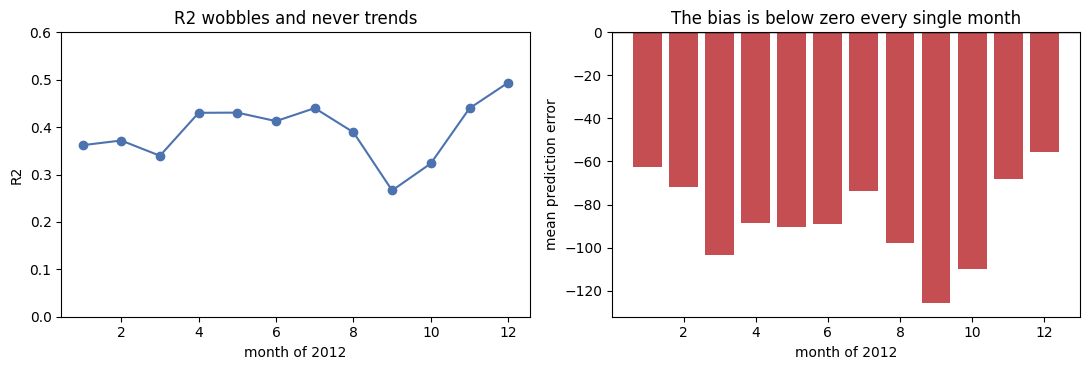

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
months = [m[0] for m in monthly]
axes[0].plot(months, [m[1] for m in monthly], 'o-', color='#4c72b0')
axes[0].set_ylim(0, 0.6); axes[0].set_xlabel('month of 2012'); axes[0].set_ylabel('R2')
axes[0].set_title('R2 wobbles and never trends')
axes[1].bar(months, [m[2] for m in monthly], color='#c44e52')
axes[1].axhline(0, color='black', lw=1)
axes[1].set_xlabel('month of 2012'); axes[1].set_ylabel('mean prediction error')
axes[1].set_title('The bias is below zero every single month')
plt.tight_layout()
plt.show()

This is the part that makes drift hard to catch, and it is why the two panels are worth separating.

If you monitored R2, you would see it move between 0.2664 and 0.4940 across the year, correlating +0.209 with the month, which is not a trend you would act on, and you would conclude the model was noisy but stable. If you monitored the **mean error**, you would see it sitting below zero in all twelve months, between 56 and 126 rentals short, and you would know within weeks that the model had a systematic problem.

The distribution shifted, the relationship did not. The shape of the daily demand curve in 2012 correlates 0.9992 with its 2011 shape, so rush hour is still rush hour; there is simply 63% more of everything. A model with a fixed intercept cannot represent that, so it is wrong in a consistent direction rather than an erratic one.

Which suggests the fix, and lets us check whether it works:

In [16]:
print('retraining on everything available before each month:')
for month in (1, 4, 7, 10):
    cutoff = pd.Timestamp(2012, month, 1)
    history_rows = usable[usable['dteday'] < cutoff]
    block = usable[(usable['year'] == 2012) & (usable['dteday'].dt.month == month)]
    refreshed = bike_model([]).fit(history_rows[BIKE_BASE], history_rows['cnt'])
    print('  2012-%02d   %5d rows of history   refreshed R2 %+.4f   frozen 2011 model %+.4f'
          % (month, len(history_rows),
             r2_score(block['cnt'], refreshed.predict(block[BIKE_BASE])),
             monthly[month - 1][1]))

retraining on everything available before each month:
  2012-01    8644 rows of history   refreshed R2 +0.3619   frozen 2011 model +0.3619
  2012-04   10820 rows of history   refreshed R2 +0.4731   frozen 2011 model +0.4302
  2012-07   13002 rows of history   refreshed R2 +0.5148   frozen 2011 model +0.4401
  2012-10   15210 rows of history   refreshed R2 +0.4779   frozen 2011 model +0.3234


Retraining recovers most of it, and the gap widens as the frozen model ages: identical in January, when "everything before" is exactly the 2011 training set, and 0.4779 against 0.3234 by October.

Three things to take from this:

- **monitor inputs and residuals, not just the score.** The score was ambiguous all year. The mean error was unambiguous from the first month
- **a scheduled retrain is a feature of the system, not an admission of failure.** Nothing was wrong with the 2011 model except that it was from 2011
- **use a time-based split whenever rows have an order.** The random `KFold` estimate of 0.6253 was not a mistake in arithmetic, it was an answer to a question nobody asked, because it let the model learn from December to predict June

### 6. The metric is a business decision, not a modelling one

Notebook 6 found that the same change to a spam model was worth +0.0033 of AUC and +0.0872 of recall, and that which of those you quote decides whether the change looks worthwhile. That was about choosing a metric. This is the sharper version of it.

AUC summarises a model across every possible threshold. Nobody deploys every possible threshold. Deploying means picking one, and that single choice moves the thing your colleagues actually care about far more than any feature in this notebook did.

In [17]:
churn_model = make_pipe().fit(X_tr, y_tr)
scores = churn_model.predict_proba(X_te)[:, 1]
print('ROC AUC %.4f, and it is the same number for every row below' % roc_auc_score(y_te, scores))
print()
print(' threshold   flagged   recall   precision   f1')
for threshold in (0.60, 0.50, 0.40, 0.30, 0.25, 0.20):
    flagged = (scores >= threshold).astype(int)
    print('     %.2f    %5d     %.4f     %.4f    %.4f'
          % (threshold, flagged.sum(), recall_score(y_te, flagged),
             precision_score(y_te, flagged), f1_score(y_te, flagged)))
print()
print('%d of the %d held-out customers actually churned' % (y_te.sum(), len(y_te)))

ROC AUC 0.8360, and it is the same number for every row below

 threshold   flagged   recall   precision   f1
     0.60      296     0.3601     0.6824    0.4714
     0.50      459     0.5330     0.6514    0.5863
     0.40      638     0.6684     0.5878    0.6255
     0.30      836     0.7754     0.5203    0.6228
     0.25      951     0.8235     0.4858    0.6111
     0.20     1040     0.8503     0.4587    0.5959

561 of the 2110 held-out customers actually churned


One model, one AUC, and a recall that runs from 0.3601 to 0.8503 depending on a number you choose.

At the default 0.50 the model catches just over half the customers who leave. At 0.25 it catches 82%, and flags 951 customers instead of 459 to do it. Neither is more correct. The answer depends on what a retention offer costs and what a departing customer is worth, and that is a conversation with the business, not a hyperparameter.

The reason this belongs in a pitfalls notebook is that `0.5` is a default nobody chose. It arrives free with `predict()`, it is almost never the right operating point for an imbalanced problem, and a model can be judged a failure entirely because of it.

### 7. Working by hypothesis, and writing down why

Section 3 showed what happens when features are proposed by a random number generator and judged only by a validation score. The defence is not a better statistical test. It is having a reason.

The loop that works is small: say what you think is true about the domain and why, build the feature that would show it, measure it on held-out data, and then look at where the model is still wrong to find the next hypothesis. The series is a worked example of it. `num_services` came from noticing that nine service columns were being ignored. `Contract` as an ordinal came from knowing that a two-year contract is a commitment and not a category. Neither came from a search.

The practical test is whether you can finish the sentence "I added this because...". If you cannot, the feature is a validation-set coincidence with extra steps.

Which is also what a feature registry is for. Every number in this one was measured somewhere in this series, and the last column is the one people forget to write down.

In [18]:
registry = pd.DataFrame([
    dict(feature='log_tenure, tenure_squared',
         source='tenure', hypothesis='churn falls steeply then flattens, so the effect is not linear',
         measured='+0.0072 over raw numeric', notebook='1, 3',
         watch_out='two columns for one idea; a spline would do the same job'),
    dict(feature='num_services',
         source='9 service columns', hypothesis='customers with more of the product are more entangled with it',
         measured='+0.0082 in the chain', notebook='7',
         watch_out='univariate AUC 0.4967; the relationship is an inverted U, and it is partly Contract in disguise'),
    dict(feature='Contract (ordinal)',
         source='Contract', hypothesis='month-to-month, one year, two year is a commitment ladder, not three labels',
         measured='+0.0126, the largest single gain', notebook='4',
         watch_out='the category order must be stated explicitly or it is arbitrary'),
    dict(feature='bundle (target encoded)',
         source='9 service columns joined', hypothesis='the combination of services says more than the count',
         measured='+0.0163 alone, +0.0017 in the full model', notebook='4, 9',
         watch_out='322 categories; must be cross-fitted or it leaks 0.0201'),
])
pd.set_option('display.max_colwidth', 52)
print(registry[['feature', 'hypothesis', 'measured']].to_string(index=False))
print()
print('the column that saves you later:')
for _, row in registry.iterrows():
    print('  %-26s %s' % (row['feature'], row['watch_out']))

                   feature                                                                  hypothesis                                 measured
log_tenure, tenure_squared              churn falls steeply then flattens, so the effect is not linear                 +0.0072 over raw numeric
              num_services               customers with more of the product are more entangled with it                     +0.0082 in the chain
        Contract (ordinal) month-to-month, one year, two year is a commitment ladder, not three labels         +0.0126, the largest single gain
   bundle (target encoded)                        the combination of services says more than the count +0.0163 alone, +0.0017 in the full model

the column that saves you later:
  log_tenure, tenure_squared two columns for one idea; a spline would do the same job
  num_services               univariate AUC 0.4967; the relationship is an inverted U, and it is partly Contract in disguise
  Contract (ordinal)         the ca

The `watch_out` column is the one that pays for itself. Six months from now, nobody will remember that `bundle` leaks two points of AUC if you target-encode it the obvious way, or that `num_services` looks worthless under a univariate screen and is not. Somebody will run a routine feature-selection pass, see 0.4967, drop it, and never find out what they lost.

### 8. What the series covered

Ten notebooks, one dataset running through most of them, and one rule that kept reappearing until notebook 9 made it structural.

- **1, Foundations.** What a feature is, why the target is not one, and the identifier trap: `customerID` scores 100% on training rows and 61.3% on test, below the 73.5% you get from guessing the majority class.
- **2, Cleaning.** Missingness that carries information, imputers ranked against ground truth, and outliers that turn out to be a shared ticket rather than an error.
- **3, Numeric transformations.** Scaling changes units and not shape, trees do not care, and raw polynomial expansion drove R2 to -11.16 before a log transform rescued it to 0.6505.
- **4, Categorical encoding.** Ordinal order is knowledge you supply, one-hot on 322 categories is worse than dropping the column, and target encoding leaks about two points of AUC unless it is cross-fitted.
- **5, Datetime.** Cyclical encoding is not automatically right; one-hot on 24 hours beat sine and cosine 0.6006 to 0.4236, because one sinusoid can only make one peak and demand has two.
- **6, Text.** Nine hand-built style features beat a 3,802-term vocabulary on F1, and sklearn's stopword list contains `not`.
- **7, Construction.** `TotalCharges` is `tenure` times `MonthlyCharges` to R2 0.999, so most arithmetic on those three columns is a new name for an old column.
- **8, Selection.** Five methods, three distinct answers, and selection done outside the fold reporting 74.5% accuracy on a coin flip.
- **9, Pipelines.** The leakage rule made structural, and each family of leak measured: 0.000001 for a scaler, 0.27 for a selector on noise.
- **10, this one.** The failures a pipeline cannot see.

If there is one habit to carry out of all of it: **measure the thing you are about to claim, on rows that had no part in the claim.** Almost every mistake in this notebook is a version of skipping that.

**Where to go next.** The obvious gap is time series, which this series does not cover: lags, rolling and expanding windows, and the forecasting-specific validation that goes with them. Section 2 here is a first taste of why it needs its own treatment. Beyond that, gradient boosting handles missing values and categoricals natively and changes which of these transformations still matter; SHAP values tell you what a model is using per prediction; and embeddings replace hand-built text features once you have the data to fit them.

### <font color='green'>Key things to remember from this notebook</font>

A correct pipeline does not make your project correct. Notebook 9 made preprocessing leakage structurally impossible, and every failure in this notebook passed straight through that pipeline without touching it.

The most expensive column is the one written down after the answer. Adding a single constructed `cancellation_ticket` flag took the honest 0.8416 to 0.9809. That is not a modelling result, it is a plumbing question, and the only reliable way to catch it is to ask when each field gets populated.

Your diagnostics can point the wrong way. The leaky model's cross-validation folds agreed with each other more tightly than the honest model's, 0.0028 against 0.0059, so every stability check reported the compromised model as the more trustworthy one.

Univariate screening cuts both ways and neither edge is sharp. The leaky column scored 0.9406 on its own, which is a genuine warning. But `num_services` scores 0.4967, a coin flip, and is worth +0.0082 to the model, because univariate AUC is blind to a non-monotone relationship.

Shift before you roll. A centred 3-hour window correlates 0.977 with the target and lifts R2 from 0.6774 to 0.9716, which anyone would catch. A centred 24-hour window correlates 0.436 against a legitimate 0.401, which nobody would catch, and still buys 0.0594 of R2 that will not exist in production. The leak that costs you money is the one small enough to survive review.

A validation set is consumed by use. Keeping 43 pure-noise features because each one nudged the validation score raised it by 0.0104 while the untouched test set moved -0.0019. That imaginary 0.0104 is bigger than four of the five real features this series added to its Telco model.

Train-test gaps are normal; growing ones are not. With 18 real columns the gap was already +0.0469. With 3,000 columns of noise the training AUC hit exactly 1.0000 and held-out AUC fell to 0.6537.

Returns diminish over a project but not in the order you find things. `Contract` as an ordinal came fourth and was the biggest single gain at +0.0126, larger than the transformations the series opened with.

Watch residuals, not only scores. A 2011 model applied through 2012 had an R2 that wandered between 0.2664 and 0.4940, correlating only +0.209 with the month, while its mean error was negative in all twelve months. Ridership had grown 63%, and only the residuals said so.

The threshold is a business decision and 0.5 is not a choice, it is a default. The same model with the same AUC catches 36% of churners at 0.60 and 85% at 0.20.

Write down why each feature exists, and what to watch out for. Nobody will remember in six months that a column with a univariate AUC of 0.4967 is one of the best features in the model.

<font color='maroon'>The one sentence: measure what you are about to claim, on rows that took no part in the claim, and be able to say why every column is there.</font>

---

That is the end of the series. Ten notebooks, and the through line was never a technique. It was the habit of checking, on data that could not have been used to produce the answer, whether the thing you believe is actually true.